In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

proc/Run


/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/utils.py:355: RuntimeWarning: Mean of empty slice
  data_trans[ii,i] = np.nanmean(data[ii, np.logical_and(Etrans_in[ii,:]>E_trans[i],Etrans_in[ii,:]<E_trans[i+1])])


NameError: name 'calibrated' is not defined

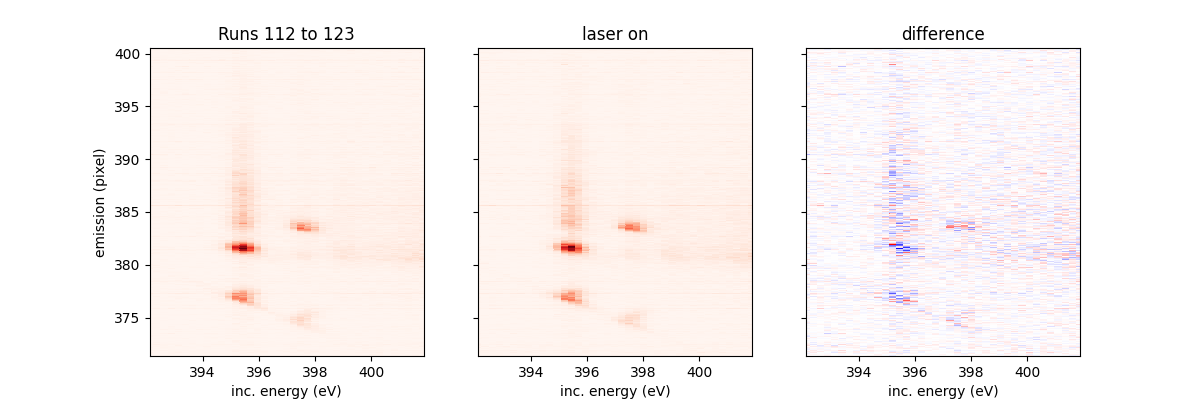

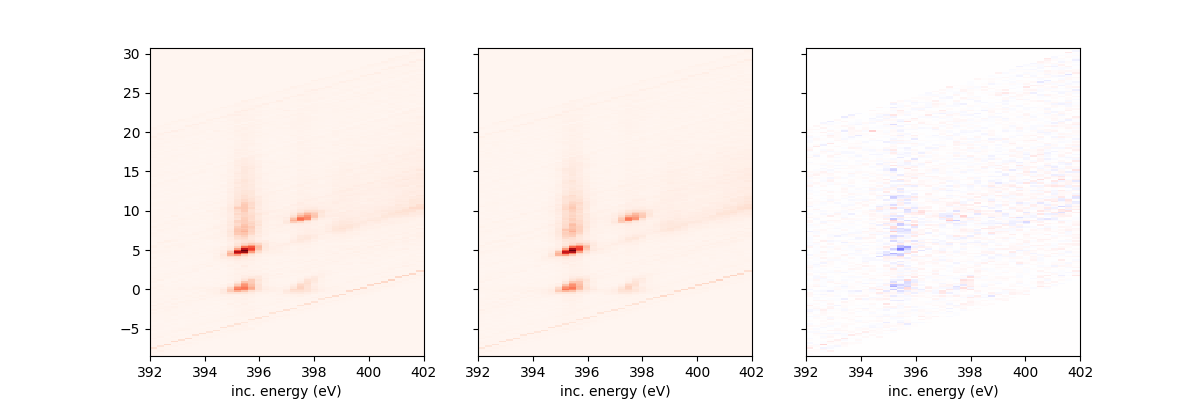

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 106
runs=[112,113,114,116,117,120,121,122,123]

exp = 'rix101331225'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=True,calibrated=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=True)
avg.plot_svls1D(figsize=(12,4))


In [46]:

emi = np.arange(avg.average['axis_svls_off_mean'].shape[1])*(-0.0366449869656799)+ 400.5108021860192
mono_off, E_trans_off, data_trans_off = emi2ET(avg.average['scanvar_off'],emi,avg.average['axis_svls_off_mean'],0.2)
            

(39, 196)

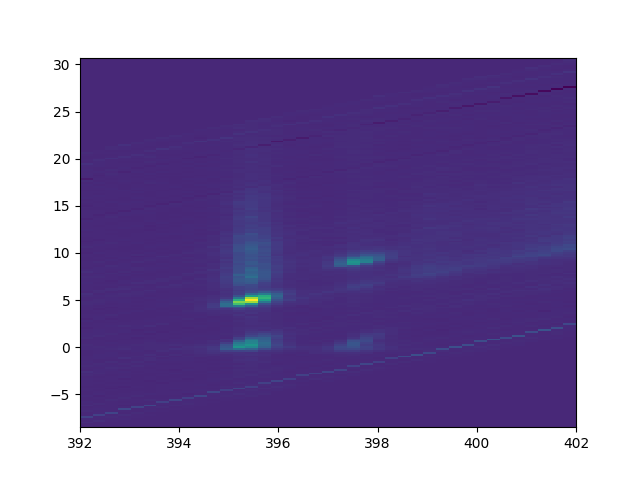

In [47]:
fig,ax=plt.subplots(1,1)
ax.pcolormesh(mono_off,E_trans_off,data_trans_off.T,shading='auto')

data_trans_off.shape

In [4]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
proc = Reduced(fname,bgname,fyaml,bgyaml)
# bg = SmallData(bgname, bgyaml)

112
setting up properties
dataset prop <functools.cached_property object at 0x7f978c0e7ed0>
dataset prop <functools.cached_property object at 0x7f978c15e390>
dataset prop <functools.cached_property object at 0x7f978bfb2d10>
dataset prop <functools.cached_property object at 0x7f978bfcad90>
dataset prop <functools.cached_property object at 0x7f97995eac50>
dataset prop <functools.cached_property object at 0x7f979987ef50>
dataset prop <functools.cached_property object at 0x7f978bfd3490>
dataset prop <functools.cached_property object at 0x7f978d26dad0>
106
setting up properties
dataset prop <functools.cached_property object at 0x7f97ae9f4590>
dataset prop <functools.cached_property object at 0x7f978c162550>
dataset prop <functools.cached_property object at 0x7f978c162c90>
dataset prop <functools.cached_property object at 0x7f978c0ee010>
dataset prop <functools.cached_property object at 0x7f978d0e57d0>
dataset prop <functools.cached_property object at 0x7f978d110a10>
scanvariable is unkown, 

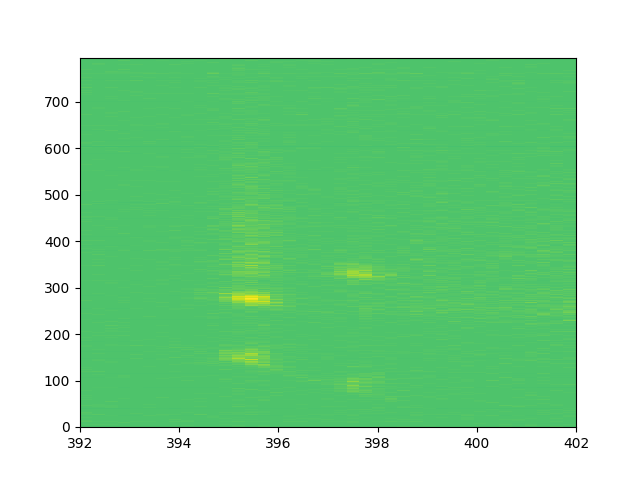

In [11]:
fig,ax=plt.subplots(1,1)
ax.pcolor(proc.scanvar_on, np.arange(proc.axis_svls_off_mean.shape[1]),(proc.axis_svls_off_mean).T)

In [39]:
def elastic_calibrate_from_two_points(
    mono,
    rixs_map_full,
    p1, p2,
    width_pixels=20,
    plot_on=True
    ):
    """
    Calibrate using a parallelogram ROI defined by two points and a fixed width.

    Parameters
    ----------
    mono : (nx,) array
        X-axis values (energy). Assumed monotonic; used on FIRST axis of rixs_map_full.
    rixs_map_full : (nx, ny) array
        2D map with first index along mono (x), second index = pixel (y).
    p1, p2 : tuple
        Two points defining the *center line* of the ROI, as (x_value_in_mono_units, y_pixel_index).
        Example: p1 = (x1, y1_pixel), p2 = (x2, y2_pixel).
    width_pixels : int or float
        Total vertical thickness of the parallelogram in pixels (constant in y).
        Top/Bottom are ±width/2 around the center line y(x) in pixel space.
    plot_on : bool
        If True, show a diagnostic plot.

    Returns
    -------
    calibrated_axis : (ny,) array
        mono ≈ a*pixel + b evaluated over all pixels.
    fit : (a, b)
        Linear fit parameters such that mono ≈ a*pixel + b.
    details : dict
        Extra info: sampled (x_mono, y_pix) of maxima, indices, etc.
    """
    mono = np.asarray(mono)
    Z = np.asarray(rixs_map_full)
    nx, ny = Z.shape

    # --- Convert the two points to (ix, iy) using mono -> x index
    x1, y1 = p1
    x2, y2 = p2
    ind_x1 = find_nearest(mono, x1)
    ind_x2 = find_nearest(mono, x2)
    px_y1 = int(round(y1))
    px_y2 = int(round(y2))
    # --- Center line
    m =(px_y2-px_y1)/(mono[ind_x2]-mono[ind_x1])
    c = px_y1-m*mono[ind_x1]

    half_w = 0.5 * float(width_pixels)

    # --- Determine x-span (in indices) to scan
    ix_start = min(ind_x1, ind_x2)
    ix_end   = max(ind_x1, ind_x2)

    x_samples = []
    ypix_at_max = []
    used_ix = []

    # --- Scan each x index within the span; search along y within top/bottom bounds
    for i in range(ix_start, ix_end + 1):
        x_here = mono[i]
        y_center = m * x_here + c
        y_lo = int(np.floor(y_center - half_w))
        y_hi = int(np.ceil (y_center + half_w))
        if y_lo > y_hi:
            y_lo, y_hi = y_hi, y_lo
        y_lo = max(0, min(ny - 1, y_lo))
        y_hi = max(0, min(ny - 1, y_hi))
        if y_hi < y_lo:
            continue

        col_slice = Z[i, y_lo:y_hi + 1]
        if col_slice.size == 0 or np.all(np.isnan(col_slice)):
            continue

        rel = int(np.nanargmax(col_slice))
        iy_max = y_lo + rel

        x_samples.append(x_here)
        ypix_at_max.append(iy_max)
        used_ix.append(i)

    x_samples = np.asarray(x_samples)
    ypix_at_max = np.asarray(ypix_at_max)

    if x_samples.size < 2:
        raise RuntimeError("Not enough maxima found within the parallelogram to fit a line.")

    # --- Fit mono ≈ a * pixel + b  (same calibration as your original)
    a, b = np.polyfit(ypix_at_max, x_samples, 1)
    calibrated_axis = np.polyval([a, b], np.arange(ny))

    # --- Optional diagnostic plot
    if plot_on:
        plt.figure(figsize=(6, 4))
        # Display Z with axes: x = mono (horizontal), y = pixel (vertical)
        plt.pcolormesh(mono,range(0,Z.shape[1]),Z.T,cmap='Reds',vmin=0,vmax=np.max(Z))
        plt.colorbar(label='Intensity')

        # Draw the two points
        # plt.scatter([mono[ind_x1], mono[ind_x2]], [px_y1, px_y2],
        #             s=60, c='white', edgecolor='k')

        # Draw center and top/bottom edges
        x_line = np.linspace(mono[ix_start], mono[ix_end], 200)
        y_center = m * x_line + c
        y_top = y_center + half_w
        y_bot = y_center - half_w
        # plt.plot(x_line, y_center, 'w--', lw=1.5, color='k',label='initial guess')
        # plt.plot(x_line, y_top,    'w-',  lw=1.0, alpha=0.8,color='k')
        # plt.plot(x_line, y_bot,    'w-',  lw=1.0, alpha=0.8,color='k')

        # Scatter maxima used for the fit
        plt.scatter(x_samples, ypix_at_max, s=20, c='yellow', edgecolor='k')

        # Plot fitted calibration line (x vs pixel)
        ypix = np.arange(ny)
        # plt.plot(np.polyval([a, b], ypix), ypix, 'r-', lw=2,
        #          label=f'fit: mono = {a:.6g} * pixel + {b:.6g}')
        plt.xlim(mono[0],mono[-1])
        plt.xlabel('Energy (mono)')
        plt.ylabel('Pixel')
        plt.title(f'Elastic Calibration via Parallelogram (width={width_pixels} px)')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    details = {
        "x_samples": x_samples,
        "ypix_at_max": ypix_at_max,
        "used_x_indices": np.array(used_ix, dtype=int),
        "center_line_m_c": (m, c),
        "width_pixels": width_pixels,
    }
    return calibrated_axis, (a, b), details

/lscratch/amke/tmp/ipykernel_950591/2912253661.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


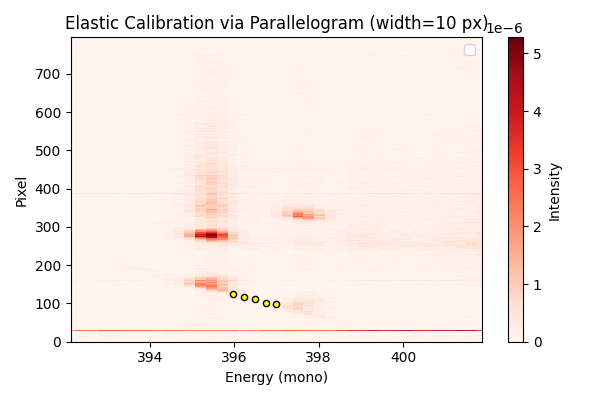

In [44]:
calibrated_axis, (a, b), details = elastic_calibrate_from_two_points(
                                    avg.average['scanvar_off'],
                                    avg.average['axis_svls_off_mean'],
                                    [396,120], [397,92],
                                    width_pixels=10,
                                    plot_on=True
                                 )

In [45]:
(a,b)

(-0.0366449869656799, 400.5108021860192)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [4]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0061.h5'


with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls'].keys())
    test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    # ax.plot(np.nanmean(file['intg']['axis_svls']['curve_corr_corrected_image'],axis=0))
    # fh = h5py.File(fname, 'r')
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]
plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()

<KeysViewHDF5 ['count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_milliJoulesPerPulse_sevr', 'lightStatus_sum_laser', 'lightStatus_sum

KeyError: "Unable to synchronously open object (object 'curve_corr_corrected_image' doesn't exist)"

In [10]:
test_ims_thresh.sum()

0.0

In [10]:
run=106
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp['intg']['axis_svls']['droplet_dense_curve_corr_pj_ax_1_data'].shape)

(3983, 796)


In [9]:
run=109
fname = f'./proc/Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp['scantype'])

KeyError: "Unable to synchronously open object (object 'scantype' doesn't exist)"